# 01 — Gemini Vision Baseline

**Mục tiêu:** Gửi prompt naive tới Gemini Vision API với **3 ảnh ngẫu nhiên từ mỗi nhóm** (15 ảnh tổng), quan sát kết quả thô, ghi chú failure pattern.

Đây là **baseline tham chiếu** — không có preprocessing, không có structured output, không có retry. Kết quả sẽ là điểm xuất phát để so sánh với các prompt/pipeline cải tiến sau.

| Nhóm | Mô tả | Số ảnh |
|---|---|---|
| 01_pos_clean | Ảnh POS rõ nét | 21 |
| 02_vat_invoice | Hoá đơn VAT điện tử | 12 |
| 03_long_invoice | Hoá đơn dài (siêu thị) | 31 |
| 04_handwritten | Viết tay | 8 |
| 05_low_quality | Chất lượng kém, mờ, nghiêng | 48 |

In [25]:
# Cell 1 — Imports
import os
import random
import csv
import time
from pathlib import Path
from datetime import datetime

# SDK mới (google-genai thay thế google-generativeai đã deprecated)
from google import genai
from google.genai import types
from dotenv import load_dotenv
import PIL.Image
from IPython.display import display, Image as IPImage, Markdown

print("google-genai ready")

google-genai ready


In [26]:
# Cell 2 — Load API key & khởi tạo client
# Phát hiện project root linh hoạt:
# - nbconvert chạy từ project root  → Path.cwd() / ".env" tồn tại
# - Jupyter Lab chạy từ notebooks/ → Path.cwd().parent / ".env" tồn tại
_cwd = Path.cwd()
if (_cwd / ".env").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / ".env").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise FileNotFoundError(f"Không tìm thấy .env trong {_cwd} hoặc {_cwd.parent}")

load_dotenv(dotenv_path=PROJECT_ROOT / ".env")

api_key = os.getenv("Gemini_API_Key")
assert api_key, "Không tìm thấy Gemini_API_Key trong .env!"

# Dùng gemini-2.0-flash: nhanh, rẻ, hỗ trợ vision tốt
MODEL = "gemini-2.5-flash-lite"
client = genai.Client(api_key=api_key)

print("Project root:", PROJECT_ROOT.resolve())
print("Model sẽ dùng:", MODEL)
print("API key (6 ký tự đầu):", api_key[:15], "...")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Project root: C:\LamHoangPhuc\AI\Smart_Receipt_VN
Model sẽ dùng: gemini-2.5-flash-lite
API key (6 ký tự đầu): AIzaSyAALCPk-fz ...


In [27]:
# Cell 3 — Sample 3 ảnh ngẫu nhiên từ mỗi nhóm
RAW_DIR = PROJECT_ROOT / "data" / "raw"

GROUPS = [
    "01_pos_clean",
    "02_vat_invoice",
    "03_long_invoice",
    "04_handwritten",
    "05_low_quality",
]

VALID_EXT = {".jpg", ".jpeg", ".png", ".gif"}
random.seed(42)  # reproducible — đổi seed để lấy bộ ảnh khác

samples = {}
for g in GROUPS:
    folder = RAW_DIR / g
    imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in VALID_EXT])
    chosen = random.sample(imgs, min(1, len(imgs)))
    samples[g] = chosen
    for p in chosen:
        print(f"  [{g}]  {p.name}")

total = sum(len(v) for v in samples.values())
print(f"\nTổng: {total} ảnh sẽ được gửi đến Gemini")

  [01_pos_clean]  pos_clean_0020.jpg
  [02_vat_invoice]  vat_invoice_0001.jpg
  [03_long_invoice]  long_invoice_0000.jpg
  [04_handwritten]  handwritten_0004.jpg
  [05_low_quality]  low_quality_0015.jpg

Tổng: 5 ảnh sẽ được gửi đến Gemini


In [28]:
# Cell 4 — Naive prompt (baseline)
# Đây là prompt đơn giản nhất có thể — không có role, không có schema, không có few-shot.
# Mục đích: quan sát Gemini "tự do" làm gì với ảnh hoá đơn Việt Nam.

NAIVE_PROMPT = """Read this receipt image and extract the information you can see.
Tell me: merchant name, date, total amount, and list of items if visible.
Reply in Vietnamese if the receipt is in Vietnamese."""

print("Prompt được dùng:")
print("-" * 60)
print(NAIVE_PROMPT)
print("-" * 60)

Prompt được dùng:
------------------------------------------------------------
Read this receipt image and extract the information you can see.
Tell me: merchant name, date, total amount, and list of items if visible.
Reply in Vietnamese if the receipt is in Vietnamese.
------------------------------------------------------------


In [30]:
# Cell 5 — Gọi Gemini cho 15 ảnh, lưu kết quả thô
# Free tier: 15 RPM → delay 5s giữa mỗi call để không bị rate limit.
# Đây là baseline thô: retry tối đa 3 lần khi bị 429, chỉ log lỗi permanent.
import time
import io

results = []
times = []

CALL_DELAY_SEC = 0   # đủ an toàn cho free tier (15 RPM)
MAX_RETRIES = 4      # số lần retry khi bị 429

def to_jpeg(img):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    buf.seek(0)
    return buf

def call_gemini_with_retry(img, prompt):
    """Retry khi 429, 503, timeout với exponential backoff."""
    for attempt in range(MAX_RETRIES):
        try:
            response = client.models.generate_content(
                model=MODEL,
                contents=[
                types.Part.from_bytes(
                    data=img.getvalue(),
                    mime_type="image/jpeg"
                ),
                    prompt
                ],
            )
            return response.text, "ok", ""

        except Exception as e:
            err_str = str(e)

            is_retryable = (
                "429" in err_str
                or "RESOURCE_EXHAUSTED" in err_str
                or "503" in err_str
                or "UNAVAILABLE" in err_str
                or "overloaded" in err_str.lower()
            )

            if is_retryable and attempt < MAX_RETRIES - 1:
                wait = 5 * (2 ** attempt)   # 5s → 10s → 20s
                print(
                    f"\n  retry {attempt+1}/{MAX_RETRIES} — chờ {wait}s...",
                    end=" ",
                    flush=True
                )
                time.sleep(wait)
            else:
                return "", "api_error", err_str

    return "", "api_error", "Max retries exceeded"

def shrink(img, max_w=900):
    w, h = img.size
    if w > max_w:
        ratio = max_w / w
        img = img.resize((max_w, int(h * ratio)))
    return img

results = []

for group, paths in samples.items():
    for i, img_path in enumerate(paths):
        start = time.perf_counter()

        print(f"Đang xử lý: {group}/{img_path.name} ...", end=" ", flush=True)

        img = PIL.Image.open(img_path)
        img = shrink(img)
        if img.mode not in ("RGB", "L"):
            img = img.convert("RGB")

        img = to_jpeg(img)
        raw_text, status, error_msg = call_gemini_with_retry(img, NAIVE_PROMPT)

        elapsed = time.perf_counter() - start
        times.append(elapsed)

        if status == "ok":
            print(f"OK ({elapsed:.2f}s)")
        else:
            print(f"ERROR ({elapsed:.2f}s) — {error_msg[:60]}")

        results.append({
            "group": group,
            "filename": img_path.name,
            "path": str(img_path),
            "status": status,
            "raw_response": raw_text,
            "error": error_msg,
            "latency_sec": elapsed,   # thêm cái này
            "quality_label": "",
            "notes": "",
        })

        if not (group == list(samples.keys())[-1] and img_path == paths[-1]):
            time.sleep(CALL_DELAY_SEC)

print(f"\nHoàn thành: {len(results)} ảnh.")
ok_count = sum(1 for r in results if r["status"] == "ok")

print(f"API thành công: {ok_count}/{len(results)}")

if times:
    print(f"\nLatency trung bình: {sum(times)/len(times):.2f}s")
    print(f"Nhanh nhất: {min(times):.2f}s")
    print(f"Chậm nhất: {max(times):.2f}s")

Đang xử lý: 01_pos_clean/pos_clean_0020.jpg ... OK (6.06s)
Đang xử lý: 02_vat_invoice/vat_invoice_0001.jpg ... OK (6.62s)
Đang xử lý: 03_long_invoice/long_invoice_0000.jpg ... OK (3.03s)
Đang xử lý: 04_handwritten/handwritten_0004.jpg ... OK (3.97s)
Đang xử lý: 05_low_quality/low_quality_0015.jpg ... OK (5.64s)

Hoàn thành: 5 ảnh.
API thành công: 5/5

Latency trung bình: 5.06s
Nhanh nhất: 3.03s
Chậm nhất: 6.62s


---
### [1/15] 01_pos_clean / `pos_clean_0020.jpg`
**API status:** ok

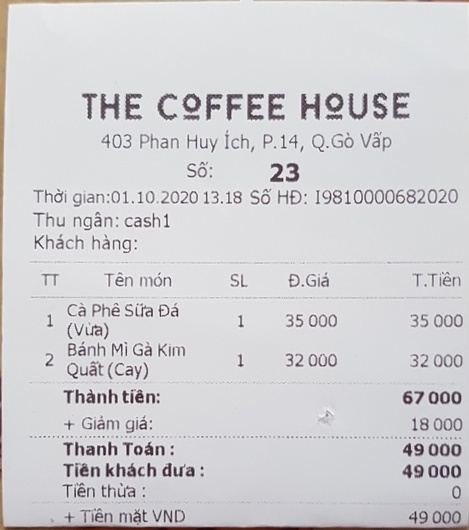

**Gemini response:**
```
Here's the information extracted from the receipt:

*   **Tên người bán:** THE COFFEE HOUSE
*   **Ngày:** 01.10.2020
*   **Tổng cộng:** 49.000
*   **Danh sách các món:**
    *   Cà Phê Sữa Đá (Vừa) - Số lượng: 1, Đơn giá: 35.000, Thành tiền: 35.000
    *   Bánh Mì Gà Kim Quất (Cay) - Số lượng: 1, Đơn giá: 32.000, Thành tiền: 32.000

**Các thông tin khác:**

*   **Địa chỉ:** 403 Phan Huy Ích, P.14, Q.Gò Vấp
*   **Số:** 23
*   **Thời gian:** 13.18
*   **Số HĐ:** 19810000682020
*   **Thu ngân:** cash1
*   **Thành tiền:** 67.000
*   **Giảm giá:** 18.000
*   **Thanh Toán:** 49.000
*   **Tiền khách đưa:** 49.000
*   **Tiền thừa:** 0
*   **Tiền mặt VND:** 49.000
```

---
### [2/15] 02_vat_invoice / `vat_invoice_0001.jpg`
**API status:** ok

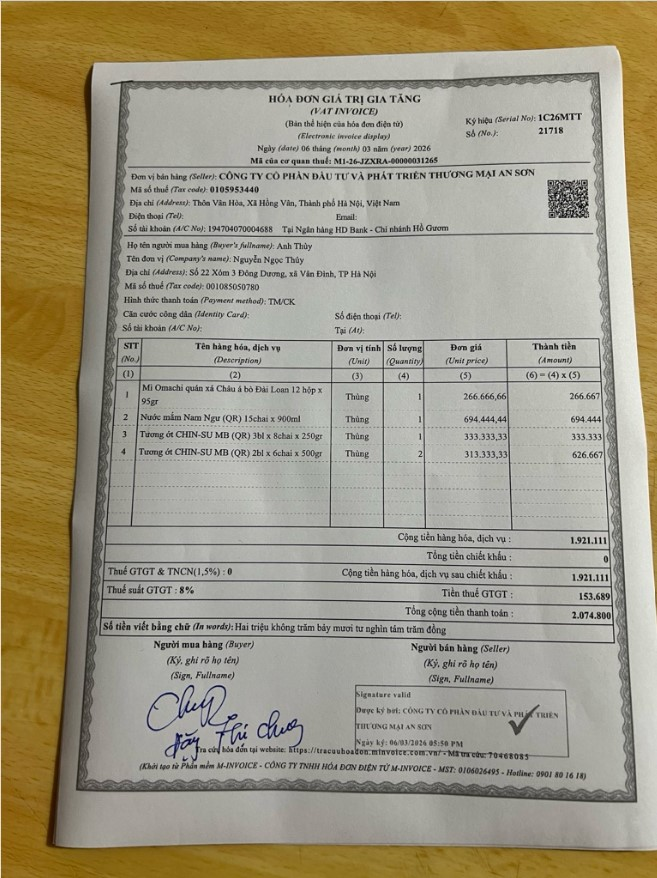

**Gemini response:**
```
Dưới đây là thông tin được trích xuất từ hóa đơn:

*   **Tên người bán:** CÔNG TY CỔ PHẦN ĐẦU TƯ VÀ PHÁT TRIỂN THƯƠNG MẠI AN SƠN
*   **Ngày:** 06 tháng (month) 03 năm (year) 2026
*   **Tổng cộng thanh toán:** 2.074.800
*   **Danh sách các mặt hàng:**
    1.  Mì Omachi quần xá Châu á bò Đài Loan 12 hộp x 95gr
    2.  Nước mắm Nam Ngư (QR) 15chai x 900ml
    3.  Tương ớt CHIN-SU MB (QR) 3b x 8chai x 250gr
    4.  Tương ớt CHIN-SU MB (QR) 2b x 6chai x 500gr
```

---
### [3/15] 03_long_invoice / `long_invoice_0000.jpg`
**API status:** ok

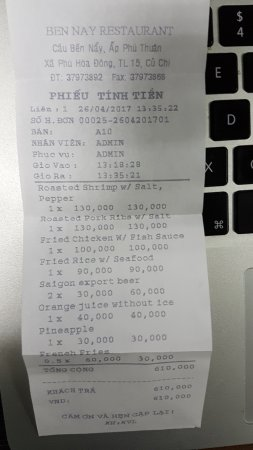

**Gemini response:**
```
BEN NAY RESTAURANT
Ngày: 26/04/2017
Tổng cộng: 610.000

Danh sách các món:
* Roasted Shrimp w/ Salt, Pepper: 130.000
* Roasted Pork Ribs w/ Salt: 130.000
* Fried Chicken w/ Fish Sauce: 100.000
* Fried Rice w/ Seafood: 90.000
* Saigon export beer: 60.000
* Orange juice without ice: 40.000
* Pineapple: 30.000
* French Fries: 30.000
```

---
### [4/15] 04_handwritten / `handwritten_0004.jpg`
**API status:** ok

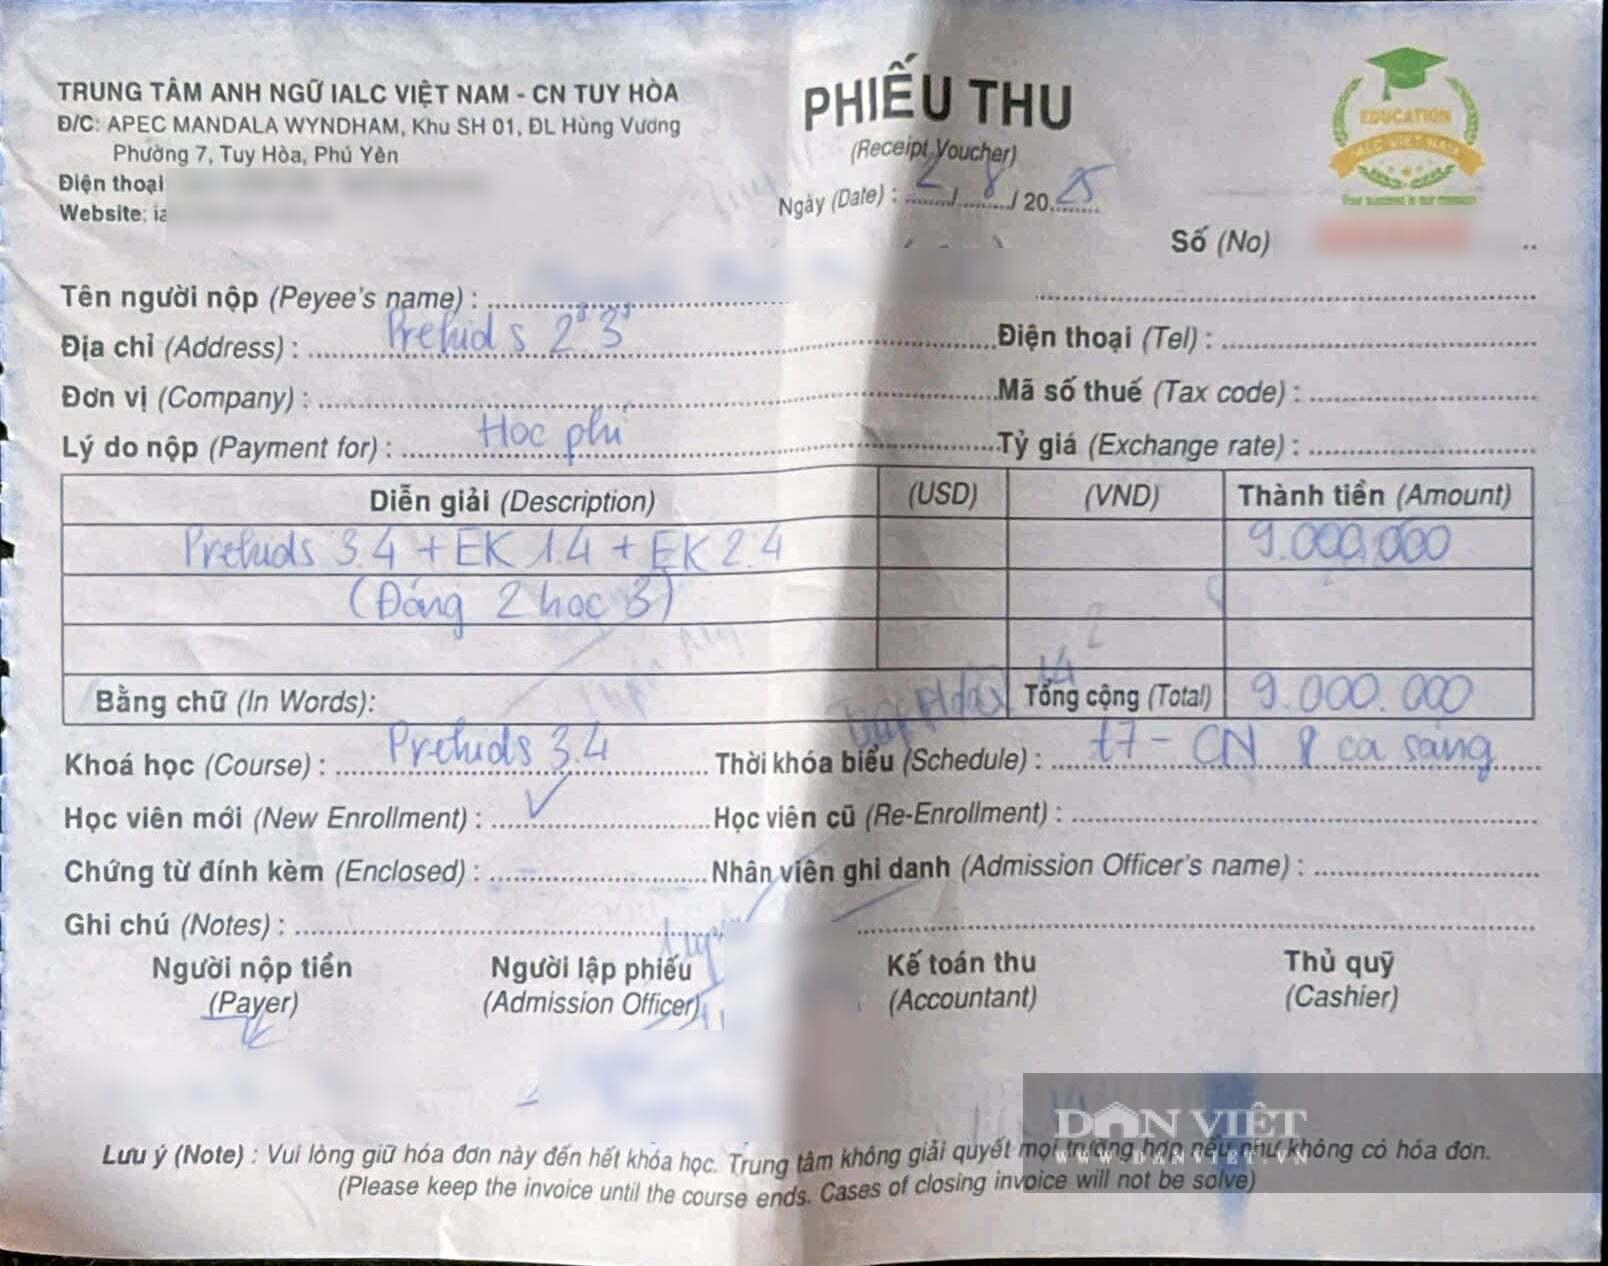

**Gemini response:**
```
Dưới đây là thông tin được trích xuất từ hóa đơn:

*   **Tên người bán:** TRUNG TÂM ANH NGỮ IALC VIỆT NAM - CN TUY HÒA
*   **Ngày:** 28/05/2025
*   **Tổng số tiền:** 9.000.000 VNĐ
*   **Danh sách các khoản mục:**
    *   Preluds 3.4 + EK 1.4 + EK 2.4 (Đóng 2 học kỳ)
    *   Bằng chữ: Chín triệu đồng
```

---
### [5/15] 05_low_quality / `low_quality_0015.jpg`
**API status:** ok

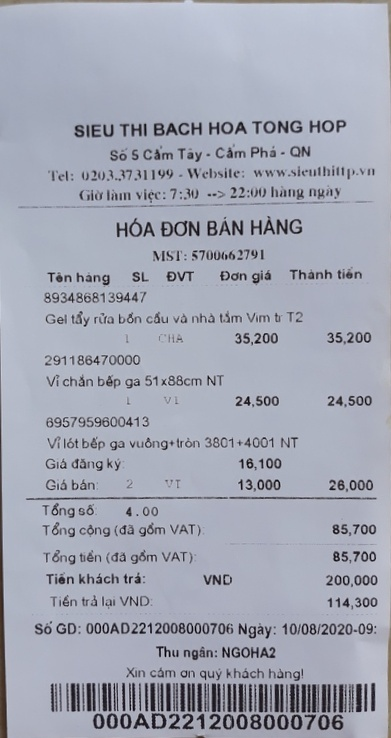

**Gemini response:**
```
Dưới đây là thông tin được trích xuất từ hóa đơn:

**Tên cửa hàng:** SIÊU THỊ BÁCH HÓA TỔNG HỢP

**Ngày:** 10/08/2020

**Tổng cộng (đã gồm VAT):** 85,700

**Danh sách các mặt hàng:**

*   **Tên hàng:** Gel tẩy rửa bồn cầu và nhà tắm Vim
    *   **Số lượng:** 1
    *   **Đơn giá:** 35,200
    *   **Thành tiền:** 35,200
*   **Tên hàng:** Vỉ chân bếp ga 51x88cm NT
    *   **Số lượng:** 1
    *   **Đơn giá:** 24,500
    *   **Thành tiền:** 24,500
*   **Tên hàng:** Vỉ lót bếp ga vuông+tròn 3801+4001 NT
    *   **Giá đăng ký:** 16,100
    *   **Số lượng:** 2
    *   **Đơn giá:** 13,000
    *   **Thành tiền:** 26,000
```

In [31]:
# Cell 6 — Hiển thị từng ảnh + response để đánh giá bằng mắt
# Sau khi chạy cell này, cuộn qua từng ảnh và ghi chú vào Cell 7.

for i, r in enumerate(results, 1):
    display(Markdown(
        f"---\n"
        f"### [{i}/15] {r['group']} / `{r['filename']}`\n"
        f"**API status:** {r['status']}"
    ))

    # Hiển thị ảnh
    try:
        display(IPImage(filename=r["path"], width=450))
    except Exception:
        display(Markdown(f"*[Không hiển thị được ảnh: {r['filename']}]*"))

    # Hiển thị response
    if r["status"] == "ok":
        preview = r["raw_response"][:1000]
        if len(r["raw_response"]) > 1000:
            preview += "\n... [truncated]"
        display(Markdown(f"**Gemini response:**\n```\n{preview}\n```"))
    else:
        display(Markdown(f"**Lỗi API:** `{r['error']}`"))

In [ ]:
# Cell 7 — Điền đánh giá thủ công sau khi xem kết quả ở Cell 6
#
# Hướng dẫn điền:
#   quality_label: "ok"      = merchant + total + items đều nhận dạng được
#                  "partial" = chỉ nhận được 1-2 fields, hoặc nhận sai một phần
#                  "fail"    = response sai hoàn toàn, không đọc được gì
#   notes: mô tả ngắn vấn đề cụ thể (ví dụ: "sai merchant", "bỏ sót items", "không đọc được chữ tay")
#
# Điền theo format: "tên_file.jpg": ("quality_label", "notes")

MANUAL_LABELS = {
    # ── Điền sau khi xem Cell 6 ──────────────────────────────────────────────
    # Ví dụ:
    # "marukame.jpg":       ("ok",      "Nhận đúng merchant, total, 3 items"),
    # "handwritten_1.jpg":  ("fail",    "Không đọc được chữ tay, response rỗng"),
    # "evn.jpg":            ("partial", "Đọc được total nhưng bỏ qua số kỳ, kỳ hạn"),
}

# Áp dụng labels vào results
for r in results:
    if r["filename"] in MANUAL_LABELS:
        r["quality_label"], r["notes"] = MANUAL_LABELS[r["filename"]]
    elif r["status"] == "api_error":
        r["quality_label"] = "fail"
        r["notes"] = f"API error: {r['error'][:100]}"

# Tổng hợp theo group
display(Markdown("## Kết quả baseline theo nhóm"))
display(Markdown(
    "| Nhóm | ok | partial | fail | Chưa đánh giá |\n"
    "|---|---|---|---|---|\n" +
    "".join(
        f"| {g} | "
        f"{sum(1 for r in results if r['group']==g and r['quality_label']=='ok')} | "
        f"{sum(1 for r in results if r['group']==g and r['quality_label']=='partial')} | "
        f"{sum(1 for r in results if r['group']==g and r['quality_label']=='fail')} | "
        f"{sum(1 for r in results if r['group']==g and not r['quality_label'])} |\n"
        for g in GROUPS
    )
))

# Liệt kê failures để phân tích pattern
failures = [r for r in results if r["quality_label"] in ("partial", "fail")]
if failures:
    display(Markdown("### Failure analysis"))
    for r in failures:
        display(Markdown(f"- **{r['filename']}** ({r['group']}): {r['notes']}"))

In [ ]:
# Cell 8 — Ghi notes vào metadata.csv
# Chỉ update dòng của 15 ảnh đã test; các dòng khác giữ nguyên.

META_PATH = PROJECT_ROOT / "data" / "metadata.csv"
label_map = {r["filename"]: r for r in results}
run_date = datetime.now().strftime("%Y%m%d")

rows = []
updated = 0
with open(META_PATH, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames
    for row in reader:
        if row["filename"] in label_map:
            r = label_map[row["filename"]]
            tag = f"[baseline_{run_date}] quality={r['quality_label']} | {r['notes']}"
            existing = row.get("notes", "").strip()
            row["notes"] = (existing + " | " + tag).strip(" | ") if existing else tag
            updated += 1
        rows.append(row)

with open(META_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"metadata.csv đã được cập nhật: {updated} dòng")
print(f"File: {META_PATH.resolve()}")

## Bước tiếp theo

Sau khi hoàn thành notebook này:

1. **Ghi lại kết quả** vào `docs/experiments/exp_001_naive_baseline.md`:
   - Bảng kết quả theo nhóm
   - Failure patterns quan sát được
   - Insight để cải thiện prompt (→ `src/extraction/prompts.py` v1)

2. **Quyết định prompt v1** dựa trên failure patterns:
   - Gemini có bỏ qua dấu tiếng Việt không?
   - Gemini có tự ý điền thông tin khi không đọc được không?
   - Format output có nhất quán không?

3. **Notebook tiếp theo:** `02_prompt_engineering.ipynb` — thêm role, schema, few-shot, đo so sánh với baseline này.